In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

In [2]:
file_path = "KDDTest+.arff"

attribute_names = []
data_started = False
data_rows = []

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()

        # Skip empty lines and comments
        if not line or line.startswith("%"):
            continue

        # Read attribute names
        if line.lower().startswith("@attribute"):
            parts = line.split()
            if len(parts) >= 2:
                attr_name = parts[1]
                attribute_names.append(attr_name)

        # Detect beginning of data
        elif line.lower() == "@data":
            data_started = True

        # Read data rows
        elif data_started:
            row = [x.strip() for x in line.split(",")]
            data_rows.append(row)

print("Total attributes:", len(attribute_names))
print("Total rows loaded:", len(data_rows))


Total attributes: 42
Total rows loaded: 22544


In [3]:
df = pd.DataFrame(data_rows, columns=attribute_names)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully
Shape: (22544, 42)


,'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',...,'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,anomaly
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,anomaly


In [4]:
# Clean column names
df.columns = [col.strip().replace("'", "").replace('"', "") for col in df.columns]

# Clean cell values
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.replace("'", "", regex=False)
    df[col] = df[col].str.replace('"', "", regex=False)

print("Columns and values cleaned successfully")
df.head()

Columns and values cleaned successfully


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,anomaly
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,anomaly


In [6]:
print("Column Names:\n")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

Column Names:

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class']

Dataset Shape:
(22544, 42)

Missing Values:

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
lan

In [7]:
target_col = df.columns[-1]
print("Target column:", target_col)

print("\nUnique target classes:")
print(df[target_col].unique())

Target column: class

Unique target classes:
<StringArray>
['anomaly', 'normal']
Length: 2, dtype: str


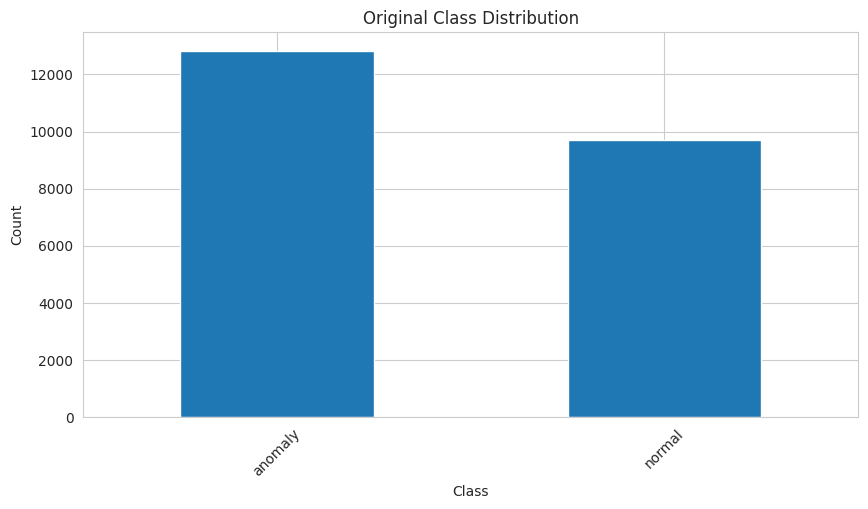

In [8]:
plt.figure(figsize=(10, 5))
df[target_col].value_counts().plot(kind="bar")
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [9]:
df["binary_class"] = df[target_col].apply(lambda x: "normal" if x == "normal" else "attack")

print(df["binary_class"].value_counts())

binary_class
attack    12833
normal     9711
Name: count, dtype: int64


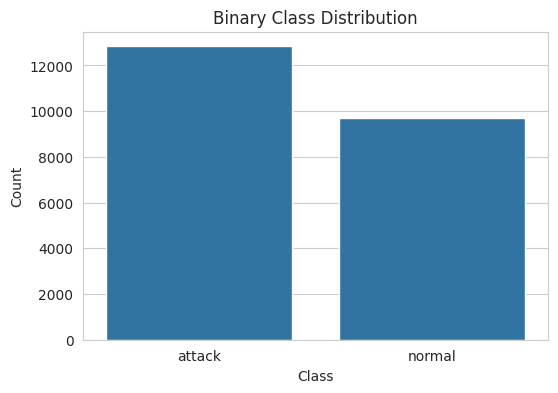

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x="binary_class", data=df)
plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [11]:
X = df.drop(columns=[target_col, "binary_class"])
y = df["binary_class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (22544, 41)
Target shape: (22544,)


In [12]:
X = X.copy()

for col in X.columns:
    try:
        X[col] = pd.to_numeric(X[col])
    except:
        pass

print(X.dtypes)

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [13]:
categorical_cols = X.select_dtypes(include=["object"]).columns
print("Categorical Columns:", categorical_cols.tolist())

Categorical Columns: ['protocol_type', 'service', 'flag']


In [14]:
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded successfully")
X_encoded.head()

Categorical columns encoded successfully


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,45,1,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00
1,0,1,45,1,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00
2,2,1,19,9,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00
3,0,0,13,9,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00
4,1,1,55,2,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71


In [15]:
X_encoded = X_encoded.fillna(0)

print("Total missing values after handling:", X_encoded.isnull().sum().sum())

Total missing values after handling: 0


In [16]:
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Target classes:", target_encoder.classes_)

Target classes: ['attack' 'normal']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (15780, 41)
Testing set shape: (6764, 41)


In [18]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


In [19]:
y_pred = dt_model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.979
Precision: 0.9873
Recall   : 0.9636
F1-Score : 0.9753


In [21]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Classification Report:

              precision    recall  f1-score   support

      attack       0.97      0.99      0.98      3850
      normal       0.99      0.96      0.98      2914

    accuracy                           0.98      6764
   macro avg       0.98      0.98      0.98      6764
weighted avg       0.98      0.98      0.98      6764



In [22]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[3814   36]
 [ 106 2808]]


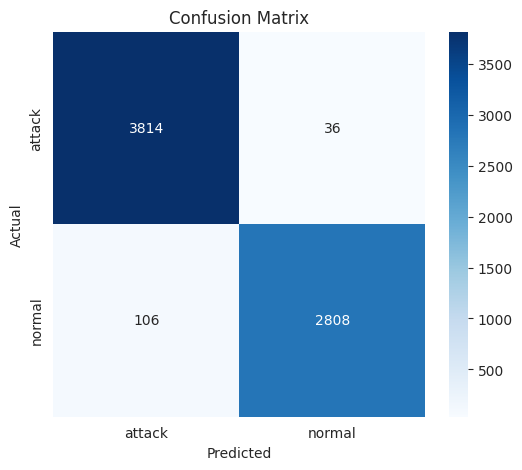

In [23]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
feature_importance.head(10)

,Feature,Importance
4,src_bytes,0.513373
39,dst_host_rerror_rate,0.146552
5,dst_bytes,0.127237
9,hot,0.040061
33,dst_host_same_srv_rate,0.024512
35,dst_host_same_src_port_rate,0.023579
2,service,0.022004
32,dst_host_srv_count,0.018910
23,srv_count,0.014684
11,logged_in,0.013583


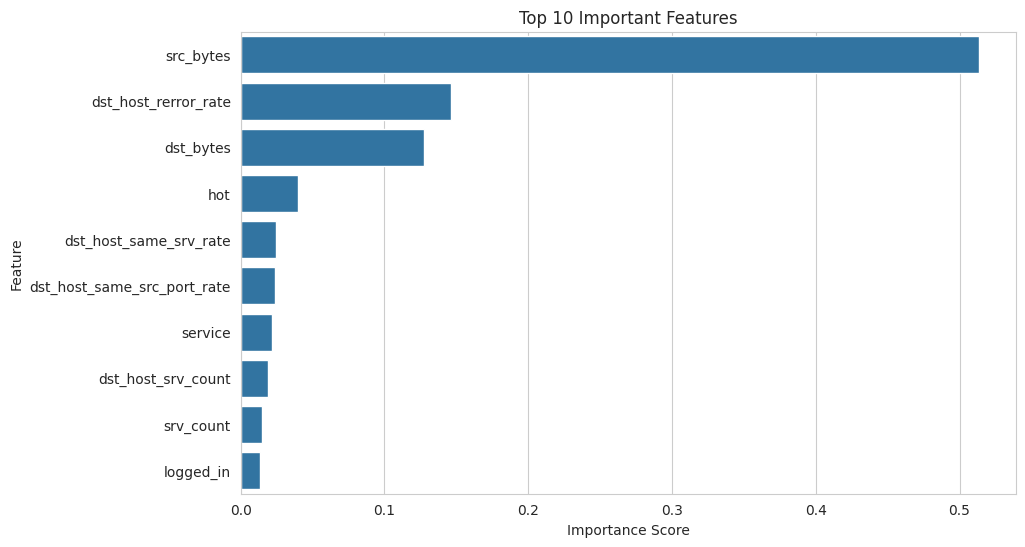

In [25]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=top_features)
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

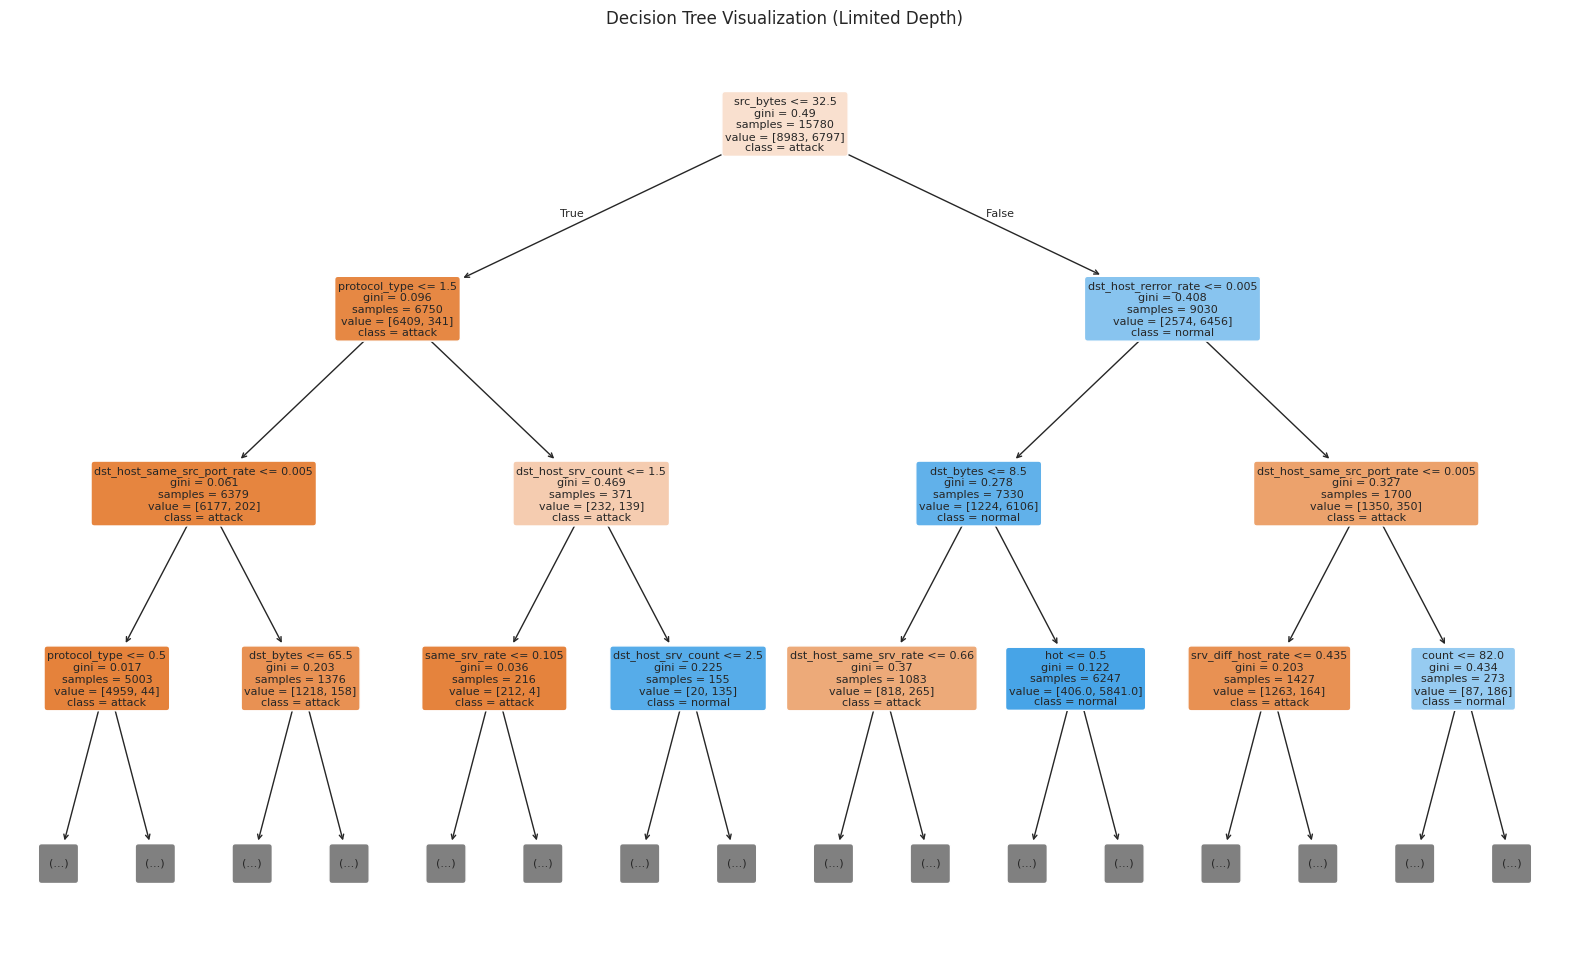

In [26]:
plt.figure(figsize=(20, 12))
plot_tree(
    dt_model,
    feature_names=X_encoded.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree Visualization (Limited Depth)")
plt.show()

In [27]:
print("Result Summary")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nModel used: Decision Tree Classifier")
print("Task: Intrusion Detection (Binary Classification: normal vs attack)")

Result Summary
----------------------------------------
Accuracy : 0.9790
Precision: 0.9873
Recall   : 0.9636
F1-Score : 0.9753

Model used: Decision Tree Classifier
Task: Intrusion Detection (Binary Classification: normal vs attack)
